# Binary footware classifcation

In [35]:
import torchvision
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader

In [36]:
rawTrain = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
rawTest = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)

XTrain = rawTrain.data
XTest = rawTest.data

yTrain = rawTrain.targets
yTest = rawTest.targets

XTrain, XTest, yTrain, yTest

(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0

In [37]:
yTrain = ((yTrain == 5) | (yTrain == 7) | (yTrain == 9)).double()
yTest = ((yTest == 5) | (yTest == 7) | (yTest == 9)).double()
yTrain, yTest

(tensor([1., 0., 0.,  ..., 0., 0., 1.]),
 tensor([1., 0., 0.,  ..., 0., 0., 1.]))

In [38]:

yTrain = yTrain.reshape(-1, 1)
yTest = yTest.reshape(-1, 1)
yTrain, yTest

(tensor([[1.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [1.]]),
 tensor([[1.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [1.]]))

In [39]:
torch.set_default_dtype(torch.float64)
XTrain = torch.tensor(XTrain / 255)
XTest = torch.tensor(XTest / 255)
XTrain, XTest

/tmp/ipykernel_4941/3466273115.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XTrain = torch.tensor(XTrain / 255)
/tmp/ipykernel_4941/3466273115.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XTest = torch.tensor(XTest / 255)


(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [40]:
def displayImage(img):
    plt.imshow(img, cmap="binary")
    plt.axis("off")


In [41]:
x = ((0.90 + 0.2) * torch.rand(XTrain.shape, dtype=torch.float64))
x

tensor([[[0.1663, 0.7228, 0.5717,  ..., 0.1051, 0.8959, 0.9911],
         [1.0985, 0.3332, 0.0058,  ..., 0.5824, 0.9044, 0.9795],
         [0.9991, 0.1473, 0.8515,  ..., 0.2652, 0.2095, 0.9566],
         ...,
         [0.1451, 1.0593, 0.1524,  ..., 0.8884, 0.0193, 0.1567],
         [0.5972, 1.0034, 0.8383,  ..., 0.9882, 1.0031, 1.0100],
         [0.7493, 0.1642, 0.1768,  ..., 0.9791, 0.7293, 1.0815]],

        [[1.0190, 0.4613, 0.7993,  ..., 0.1346, 0.2091, 1.0850],
         [0.3711, 0.2948, 0.9212,  ..., 0.0159, 0.2913, 0.6918],
         [0.9548, 0.6406, 0.3699,  ..., 0.1876, 0.6947, 0.7979],
         ...,
         [0.2577, 0.9143, 0.5576,  ..., 0.0204, 0.9003, 0.7377],
         [0.6373, 1.0603, 0.4158,  ..., 0.0587, 0.1665, 0.4338],
         [0.7243, 0.2909, 0.5008,  ..., 0.9101, 0.5627, 0.7135]],

        [[0.8290, 0.9039, 0.2124,  ..., 0.1731, 1.0778, 0.8913],
         [0.9632, 0.2789, 0.3834,  ..., 1.0143, 0.9783, 0.6536],
         [0.1593, 0.5228, 0.8828,  ..., 0.9467, 0.3384, 0.

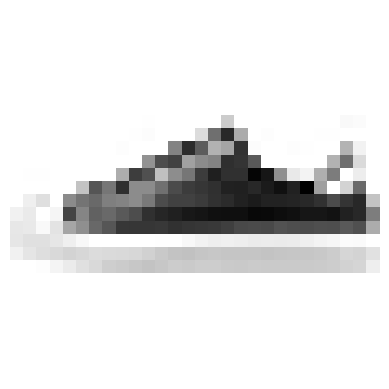

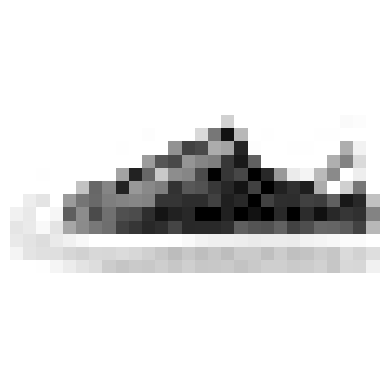

In [42]:
randomIndex = np.random.randint(0, 60000)
displayImage(XTrain[randomIndex])
plt.show()
XTrainRandomPattern = torch.clamp((XTrain.detach().clone() * (0.85 + 0.3 * torch.rand(XTrain.shape, dtype=torch.float64))), min=0, max=1)
displayImage(XTrainRandomPattern[randomIndex])
plt.show()

In [43]:
XTrainExtended = torch.concat((XTrain, XTrainRandomPattern), axis= 0)
XTrainExtended.shape

torch.Size([120000, 28, 28])

In [44]:
yTrainExtended = torch.concat((yTrain, yTrain), axis= 0)
yTrainExtended.shape

torch.Size([120000, 1])

In [45]:
class DataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]


trainDataSet = DataSet(XTrainExtended, yTrainExtended)
evalDataSet = DataSet(XTest, yTest)

In [46]:

trainLoader = DataLoader(trainDataSet, batch_size=32, shuffle=True)

evalLoader = DataLoader(evalDataSet, batch_size=XTest.shape[0], shuffle=False)


# Model making and training

In [47]:
torch.manual_seed(67)
class FootwareClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.neuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.neuralNetwork(X)

In [48]:
model = FootwareClassifier().double()
summary(model, input_size= (32, 28, 28), 
    dtypes=[torch.float64])

Layer (type:depth-idx)                   Output Shape              Param #
FootwareClassifier                       [32, 1]                   --
├─Sequential: 1-1                        [32, 1]                   --
│    └─Flatten: 2-1                      [32, 784]                 --
│    └─Linear: 2-2                       [32, 128]                 100,480
│    └─ReLU: 2-3                         [32, 128]                 --
│    └─Linear: 2-4                       [32, 128]                 16,512
│    └─ReLU: 2-5                         [32, 128]                 --
│    └─Linear: 2-6                       [32, 128]                 16,512
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Linear: 2-8                       [32, 1]                   129
│    └─Sigmoid: 2-9                      [32, 1]                   --
Total params: 133,633
Trainable params: 133,633
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.28
Input size (MB): 0.20
Forward

In [56]:
torch.set_num_threads(10)
epochs = 100
alpha = 0.0007

lossFunction = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=alpha)

trainLossH = []
evalLossH = []

trainAccuracyH = []
evalAccuracyH = []

for epoch in range(epochs):

    losses = []
    accuracies = []

    for X, y in trainLoader:

        yHat = model(X)
        loss = lossFunction(yHat, y)

        losses.append(loss.item())
        yHat = (yHat > 0.5).int()
        accuracy = (yHat == y).float().mean()
        accuracies.append(accuracy.item())

        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)

    if((epoch + 1) % 1 == 0):

        model.eval()

        with torch.no_grad():

            for X, y in evalLoader:

                yEval = model(X)
                evalLoss = lossFunction(yEval, y)
                evalLossH.append(evalLoss.item())

                trainAccuracyH.append(accuracy)
                trainLossH.append(loss)

                yEval = (yEval > 0.5).int()
                evalAccuracy = (yEval == y).float().mean()
                evalAccuracyH.append(evalAccuracy.item())

                print(
                    f"Epoch: {epoch + 1}, "
                    f"train loss: {loss}, "
                    f"train accuracy: {accuracy * 100:.2f}% | "
                    f"evaluation loss: {evalLoss.item()}, "
                    f"evaluation accuracy: {evalAccuracy.item() * 100:.2f}%"
                )

        model.train()

Epoch: 1, train loss: 0.0010748161318267088, train accuracy: 99.98% | evaluation loss: 0.0010774431235812544, evaluation accuracy: 99.97%
Epoch: 2, train loss: 0.00106245677522396, train accuracy: 99.98% | evaluation loss: 0.0010702505582536144, evaluation accuracy: 99.97%
Epoch: 3, train loss: 0.0010557518015163175, train accuracy: 99.98% | evaluation loss: 0.0010661289540717092, evaluation accuracy: 99.97%
Epoch: 4, train loss: 0.0010464024186549823, train accuracy: 99.98% | evaluation loss: 0.0010580042482174997, evaluation accuracy: 99.98%
Epoch: 5, train loss: 0.0010404221853926405, train accuracy: 99.97% | evaluation loss: 0.0010460963474976288, evaluation accuracy: 99.97%
Epoch: 6, train loss: 0.0010287324757361992, train accuracy: 99.98% | evaluation loss: 0.001050817491110909, evaluation accuracy: 99.98%
Epoch: 7, train loss: 0.0010281245933290812, train accuracy: 99.98% | evaluation loss: 0.0010320373393696877, evaluation accuracy: 99.98%
Epoch: 8, train loss: 0.0010181328756

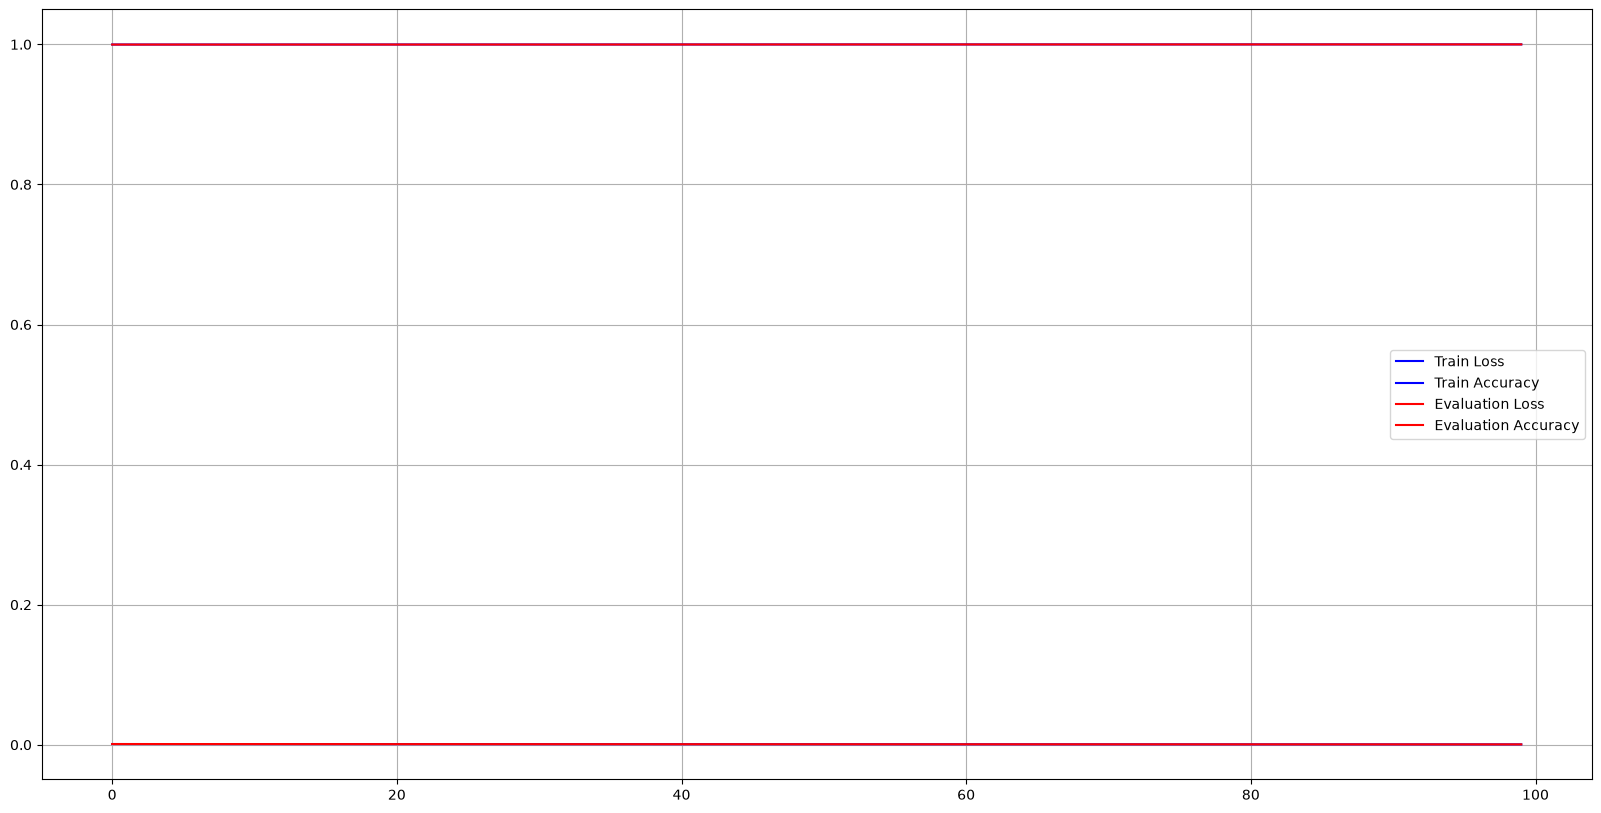

In [57]:
plt.figure(figsize=(20, 10))
plt.grid(True)
plt.plot(trainLossH, c="b", label = "Train Loss")
plt.plot(trainAccuracyH, c = "b", label = "Train Accuracy")
plt.plot(evalLossH, c = "r", label = "Evaluation Loss")
plt.plot(evalAccuracyH, c = "r", label = "Evaluation Accuracy")
plt.legend(loc="best")
plt.show()

In [59]:
torch.save(model.state_dict(), "mnist_footware_classification.pth")